# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [67]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [68]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [69]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [70]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [71]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [72]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [73]:
# inspección de plans con .info() 
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [74]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [75]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


In [76]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos
print(users.isna().mean()) # Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [77]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**:
💡 * Hint:
  
* *Dataset*:`Users`
    - **City**: presenta 469 valores nulos (11.7% del total), lo que significa una falta parcial de datos geográficos.
        - Acción: Investigar e imputar con un valor como "Desconocido" o la moda, ya que el porcentaje es manejable, representa un valor inferior al 30%.
    - **Churn_date**: presenta 3534 valores nulos (88.35% del total), lo que es normal, ya que la mayoría de los usuarios siguen activos, aún no tienen fecha de baja.
        - Acción: Ignorar o mantener los nulos, ya que estos representan a los clientes que aún están activos en la empresa.
      
* *Dataset*: `Usage` 
    - **Date**: presenta 50 valores nulos (0.13% del total), lo que correponde a una cantidad mínima de registros sin fecha.
        - Acción: Eliminar estas filas o ignorarlas, dado que representan menos del 5% y no afectan la integridad del análisis masivo.
    - **Duration**: tiene 22076 valores nulos (55.19% del total), estos son más de la mitad de los registros, lo cuales no tienen duración de llamada.
        - Acción: se recomienda ignorar o mantener, pues es probable que estos nulos correspondan a filas tipo 'text' (mensajes) donde la duración no aplica.
    - **Lenght**:  posee 17896 valores nulos (44.74% del total), casi la mitad de los registros no tienen longitud de mensaje.
        - Acción: Ignorar o mantener, ya que estos nulos deben corresponder a filas tipo 'call' (llamadas) donde no existe conteo de caracteres.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [78]:

# explorar columnas numéricas de users


std_user_id = users['user_id'].describe()
print(std_user_id)
std_age= users['age'].describe()
print(std_age)




count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64
count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


- La columna `user_id` los valores van de 10000 a 13999 con una distribución uniforme, los datos son consistentes; no se detectan valores atipicos ni sentinels en los IDs. 
- La columna `age` el valor mínimo es -999, mientras que la mediana es 47 años. Se detectó un sentinel (-999), este valor es un error o un marcador de dato faltante, ya que no existen edades negativas. En este caso como este valor puede estar afectando el promedio, se debe filtrar estos valores y reemplazarlos por la mediana o eliminarlos si son pocos.

In [79]:
# explorar columnas numéricas de usage
std_id = usage['id'].describe()
print(std_id)
std_us_id= usage['user_id'].describe()
print(std_us_id)



count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64
count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64


- Las columnas `id` y `user_id` presentan datos consistentes con el dataset de `usage`.
- En `id` los valores están en un rango de 1 a 40.000, lo que coincide con el número de filas; no presenta nulos.
- En `user_id`los valores oscilan entre 10.000 y 13.999, con una media y mediana muy cercanos as 12.000. Los datos no presentan muy dispersión, lo que confirma que las transacciones pertenencen al rango de clientes registrados. 


In [80]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user: 
    print(f"--- Análisis de la columna: {col} ---")
    print (f"Conteo de Valores:\n{users[col].value_counts()}")
    print (f"\nValores únicos:\n{users[col].unique()}")
    print ("\n")



--- Análisis de la columna: city ---
Conteo de Valores:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores únicos:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']


--- Análisis de la columna: plan ---
Conteo de Valores:
Basico     2595
Premium    1405
Name: plan, dtype: int64

Valores únicos:
['Basico' 'Premium']




- La columna `city` presenta 808 registros en Bogotá, la ciudad más frecuente, y se detectan dos problemas de calidad: 96 registros con el sentinel **"?"** y la presencia de valores `nan`(nulos). Por lo anterior se recomienda **imputar** tanto los "?" como los `nan`. 
- La columna `plan` los datos se ven limpios y dividos en dos categorías: **Básico** con 2.595 y **Premium** con 1.405 usuarios. 

In [81]:
# explorar columna categórica de usage
print("Valores únicos:")
print(usage['type'].unique())
print("\nConteo de valores:")
print(usage['type'].value_counts()) # completa el código

Valores únicos:
['call' 'text']

Conteo de valores:
text    22092
call    17908
Name: type, dtype: int64


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

Tras la exploración estadística y de valores únicos, este es el diagnóstico de inconsistencias detectadas: 
- **Columna `age` de users**: se detectó el sentinel -999. Al ser una edad no posible, afecta el promedio.
    - Acción: Reemplazar los valores -99 por la mediana de la edad para no sesgar el análisis estadístico.
- **Columna `city` de users**: Se identificó el sentinel "?" (96 casos) y valores nan. Estos pueden representar fallas en la captura de la ubicación del cliente.
    - Acción: Imputar ambos casos bajo la categoría "Desconocido" para mantener la integridad de los registros sin perder datos de otras columnas.
- **Columnas `id` y `user_id` en usage**: No se encontraron valores inválidos, negativos ni fuera de rango. Los IDs son consistentes entre tablas. No se requeriría acción en estos.
- **Columna `type` en usage**: Presenta valores consistentes ("call" y "text") que justifican los nulos en otras columnas. Mantener, no presenta sentinels y es fundamental para el filtrado del comportamiento de uso.
- **Columna `plan`en users**: Sin valores inválidos; la distribución entre "Basico" y "Premium" es completa para los 4,000 usuarios. No requiere acciones adicionales, la columna está lista para el análisis de segmentación.
 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [82]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce") 
print (users['reg_date']) # completa el código

0      2022-01-01 00:00:00.000000000
1      2022-01-01 06:34:17.914478619
2      2022-01-01 13:08:35.828957239
3      2022-01-01 19:42:53.743435858
4      2022-01-02 02:17:11.657914478
                    ...             
3995   2024-12-29 21:42:48.342085520
3996   2024-12-30 04:17:06.256564144
3997   2024-12-30 10:51:24.171042768
3998   2024-12-30 17:25:42.085521392
3999   2024-12-31 00:00:00.000000000
Name: reg_date, Length: 4000, dtype: datetime64[ns]


In [83]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors="coerce") 
print (usage['date']) # completa el código


0       2024-01-01 00:00:00.000000000
1       2024-01-01 00:06:30.969774244
2       2024-01-01 00:13:01.939548488
3       2024-01-01 00:19:32.909322733
4       2024-01-01 00:26:03.879096977
                     ...             
39995   2024-06-29 23:33:56.120903022
39996   2024-06-29 23:40:27.090677266
39997   2024-06-29 23:46:58.060451510
39998   2024-06-29 23:53:29.030225754
39999   2024-06-30 00:00:00.000000000
Name: date, Length: 40000, dtype: datetime64[ns]


In [84]:


# Revisar los años presentes en `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

print("Conteo de registros por año:")
print(users['reg_date'].dt.year.value_counts().sort_index())



Conteo de registros por año:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, se evidencia que la gran mayoría de los registros (99%) se distribuyen de forma equitativa entre 2022, 2023 y 2024. Sin embargo, se detectaron 40 registros con el año 2026, lo cual es una anomalía ya que son fechas futuras respecto al periodo de análisis del proyecto.

In [85]:

# Revisar los años presentes en `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

print("Conteo de registros por año:")
print(usage['date'].dt.year.value_counts().sort_index())


Conteo de registros por año:
2024.0    39950
Name: date, dtype: int64


En `date`, se evidencia que el 100% de los registros cálidos, 39.950 filas, corresponden al año 2024. No se detectan años fuera de rango ni registros del futuro, como el 2026 encontrado en el otro dataset, lo que garantiza que los datos de consumo son coherentes con el periodo analizado

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? Sí, en `ref_date`(usuarios) existen 40 registros del año 2026, mientras que en `date` (uso) todos los registros son del año 2024. 
- ¿Qué harías con ellas? Se podrían mantener los datos de 2024 intactos. Para los 40 registros de 2026 en el dataset de usuarios, se podrían eliminar o corregirlos. ya que representan una inconsistencia menor (1%) que podría alterar los cálculos de antiguedad. 

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [87]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].replace(-999, np.nan).median()
users['age'] = users ['age'].replace(-999, age_mediana) 

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [89]:

# Reemplazar ? por NA en city
users["city"]= users['city'].replace('?', pd.NA)
# Verificar cambios
users['city'].describe()


count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [90]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].mask(users['reg_date'].dt.year > 2024, pd.NaT)
# Verificar cambios
print("Años presentes ahora:")
print(users['reg_date'].dt.year.value_counts())

Años presentes ahora:
2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [91]:
# Verificación MAR en usage (Missing At Random) para duration
print("Distribución de 'type' cuando 'duration' es nulo:")
print(usage[usage['duration'].isna()]['type'].value_counts())


Distribución de 'type' cuando 'duration' es nulo:
text    22076
Name: type, dtype: int64


In [93]:
# Verificación MAR en usage (Missing At Random) para length
print("\nDistribución de 'type' cuando 'length' es nulo:")
print(usage[usage['length'].isna()]['type'].value_counts())


Distribución de 'type' cuando 'length' es nulo:
call    17896
Name: type, dtype: int64


**Descripcion de diagnostico de nulos en `duration` y `length`**: 
Al realizar el cruce de variables, los datos revelan una estructura de omisión lógica:
- Se identificaron 22,076 nulos en la columna `duration`, y el 100% de ellos corresponden a registros etiquetados como type: `text`. 
- Se identificaron 17,896 nulos en la columna `length`, y el 100% de ellos corresponden a registros etiquetados como type: `call`.

Partiendo de la clasificacion MAR, la probabilidad de que un dato falte en `duration` o `length` no es aleatoria, sino que depende del valor de la columna type, ya que un mensaje de texto (text) no genera una duración de tiempo y una llamada de voz (call) no genera una longitud de caracteres.

En este sentido, se recomendaría mantener los valores nulos, ya que eliminar estas filas implicaría perder el historial completo de uso de servicios, y tampoco sería conveniente imputar con ceros (0), ya que esto sesgaría negativamente el cálculo de promedios. Un segmentación sería ideal con la limpieza de forma funcional al momento de calcular métricas (usando filtros por type).

💡 Este hallazgo es muy positivo, ya que demuestra que la base de datos es robusta y que la aparente "falta de información" es en realidad una característica del negocio.


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [96]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamadas=('duration','sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamadas
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [97]:
# Renombrar columnas
usage_agg.columns=['user_id','cant_mensajes','cant_llamadas', 'cant_minutos_llamadas']
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamadas
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [100]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamadas
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [101]:
# Resumen estadístico de las columnas numéricas
columnas_num = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamadas']
print("Resumen estadístico de consumo y edad:")
display(user_profile[columnas_num].describe())

Resumen estadístico de consumo y edad:


,age,cant_mensajes,cant_llamadas,cant_minutos_llamadas
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [102]:
# Distribución porcentual del tipo de plan
dist_plan = user_profile['plan'].value_counts(normalize=True) * 100

print("Distribución de planes (%):")
print(dist_plan)


Distribución de planes (%):
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

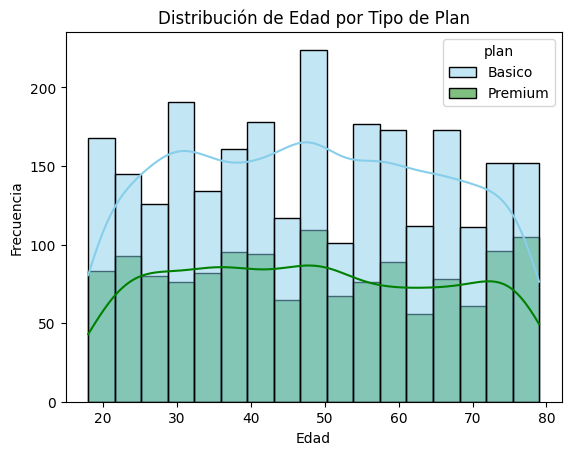

In [116]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- **Distribución**: La variable presenta una distribución uniforme. A diferencia de otros mercados donde los jóvenes o los adultos mayores dominan, aquí vemos que hay una cantidad de usuarios muy similar en casi todos los rangos de edad (desde los 18 hasta los 80 años). No hay un pico único, sino múltiples "mesetas".
    - Se observa que el plan Básico (celeste) tiene una frecuencia significativamente mayor en todos los rangos de edad en comparación con el plan Premium (verde). Esto confirma que el plan Básico es el producto principal de la compañía para cualquier etapa de la vida del usuario.
    - No existe un sesgo generacional evidente. Tanto usuarios jóvenes (20-30 años) como adultos mayores (70+ años) eligen ambos planes en proporciones similares. Esto sugiere que la elección del plan no depende de la edad, sino probablemente de otras variables como el nivel de ingresos o la necesidad técnica de datos/minutos.

    *Picos específicos*: Existe un ligero incremento de usuarios en el rango de los 45 a 50 años para ambos planes, siendo el punto de mayor volumen de clientes para la empresa. Existe una ligereza mayor en el plan básico.

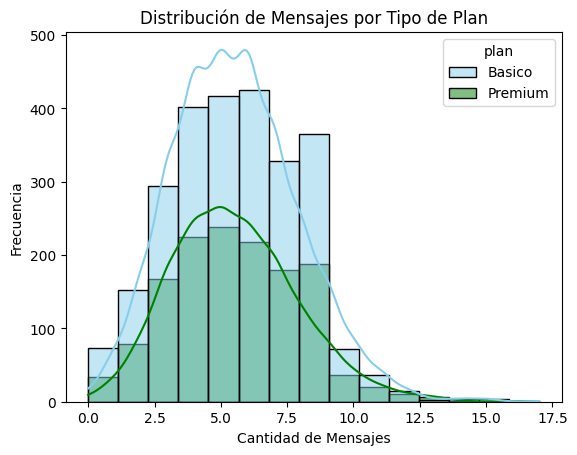

In [113]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins= 15, palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- **Distribución**: La variable sigue una distribución ligeramente sesgada a la derecha (right-skewed). La mayor concentración de usuarios envía entre 3 y 7 mensajes, y a medida que aumenta la cantidad, la frecuencia cae rápidamente. Hay una "cola" hacia la derecha que representa a los usuarios de alto consumo.
    - Los usuarios del plan Básico (celeste) dominan el volumen total de mensajes, con un pico máximo muy marcado alrededor de los 6 mensajes. Por otro lado, los usuarios del plan Premium (verde) muestran una curva más "achatada" y extendida hacia la derecha. Esto indica que, aunque son menos usuarios, tienen una mayor tendencia a realizar consumos más elevados de mensajería que los usuarios básicos.
    -  No existe una diferencia drástica en el comportamiento inicial; ambos grupos comienzan su actividad principal a partir de los 2 mensajes. Sin embargo, después de los 10 mensajes, la presencia del plan Básico desaparece casi por completo, mientras que el plan Premium sigue registrando actividad, lo que justifica la existencia de un plan superior para usuarios intensivos.
      
      *Valores Atípicos*: Se observan usuarios que envían más de 15 mensajes. Estos casos son poco frecuentes y representan el límite superior del uso del servicio en este dataset.

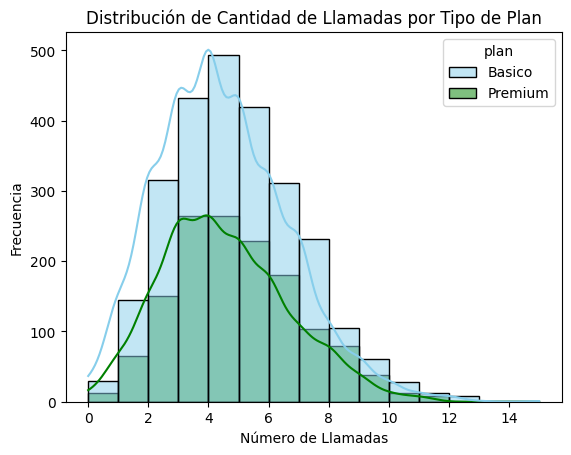

In [123]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins= 15, palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Número de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- **Distribución**:La variable presenta una distribución unimodal y simétrica, con una forma de campana definida. El comportamiento del usuario promedio está estandarizado, concentrándose la gran mayoría de la población en un rango de 2 a 6 llamadas.
    - La "moda" o el pico de actividad ocurre de manera clara entre las 4 y 5 llamadas. Este es el comportamiento típico esperado para un cliente promedio de la compañía, independientemente de su plan.
    - El plan Básico (celeste) representa el mayor volumen de la operación, dominando especialmente en los rangos de consumo medio-bajo.
    - El plan Premium (verde) muestra una distribución más equilibrada y extendida. A medida que aumenta el número de llamadas (hacia el rango de 8 a 12), la proporción de usuarios Premium se vuelve más significativa, lo que sugiere que este plan atrae a usuarios con una necesidad de comunicación más frecuente.
    - Existe una caída drástica en la frecuencia después de las 10 llamadas, lo que indica que consumos superiores a este nivel son comportamientos atípicos o de nicho que no representan al grueso de la base de clientes.

✍️ Este gráfico confirma que no hay una brecha drástica en el hábito de uso entre planes, sino más bien una diferencia de intensidad. Ambos tipos de clientes usan el servicio de manera similar, pero el plan Premium sostiene mejor a los usuarios que necesitan estar por encima del promedio.

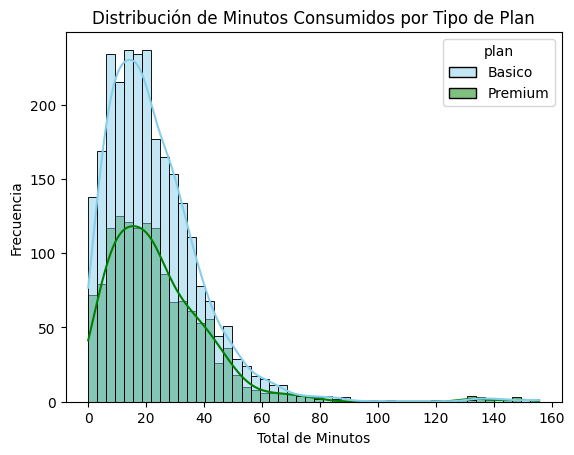

In [119]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamadas', hue='plan', bins= 50, palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Minutos Consumidos por Tipo de Plan')
plt.xlabel('Total de Minutos')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- **Distribución**: La variable presenta una clara distribución sesgada a la derecha (right-skewed). El grueso de los usuarios se concentra en consumos bajos, con una moda (el punto más alto) situada entre los 15 y 20 minutos totales. A partir de los 40 minutos, la frecuencia disminuye drásticamente.
    - El plan Básico (celeste) muestra una curva muy alta y estrecha, lo que indica que la gran mayoría de sus clientes mantiene consumos de tiempo muy similares y contenidos (pocos minutos).
    - El plan Premium (verde) tiene una curva más baja pero más ancha hacia la derecha. Esto sugiere que, proporcionalmente, hay más usuarios Premium que se atreven a realizar llamadas largas, superando los 40 o 60 minutos.

- **Presencia de Outliers**: Es muy interesante observar la "cola" de la derecha después de los 120 minutos. Existen algunos pocos usuarios (de ambos planes) que tienen un consumo extremadamente alto en comparación con el resto de la población. Estos casos podrían ser perfiles comerciales o incidentes específicos.

✍️La mayoría de los usuarios de ambos planes parecen "auto-regularse" por debajo de los 60 minutos. El hecho de que las curvas se solapen tanto en los primeros 20 minutos indica que, para un gran segmento de la población, el plan Básico es más que suficiente, mientras que el Premium solo es aprovechado al máximo por una pequeña fracción de clientes intensivos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

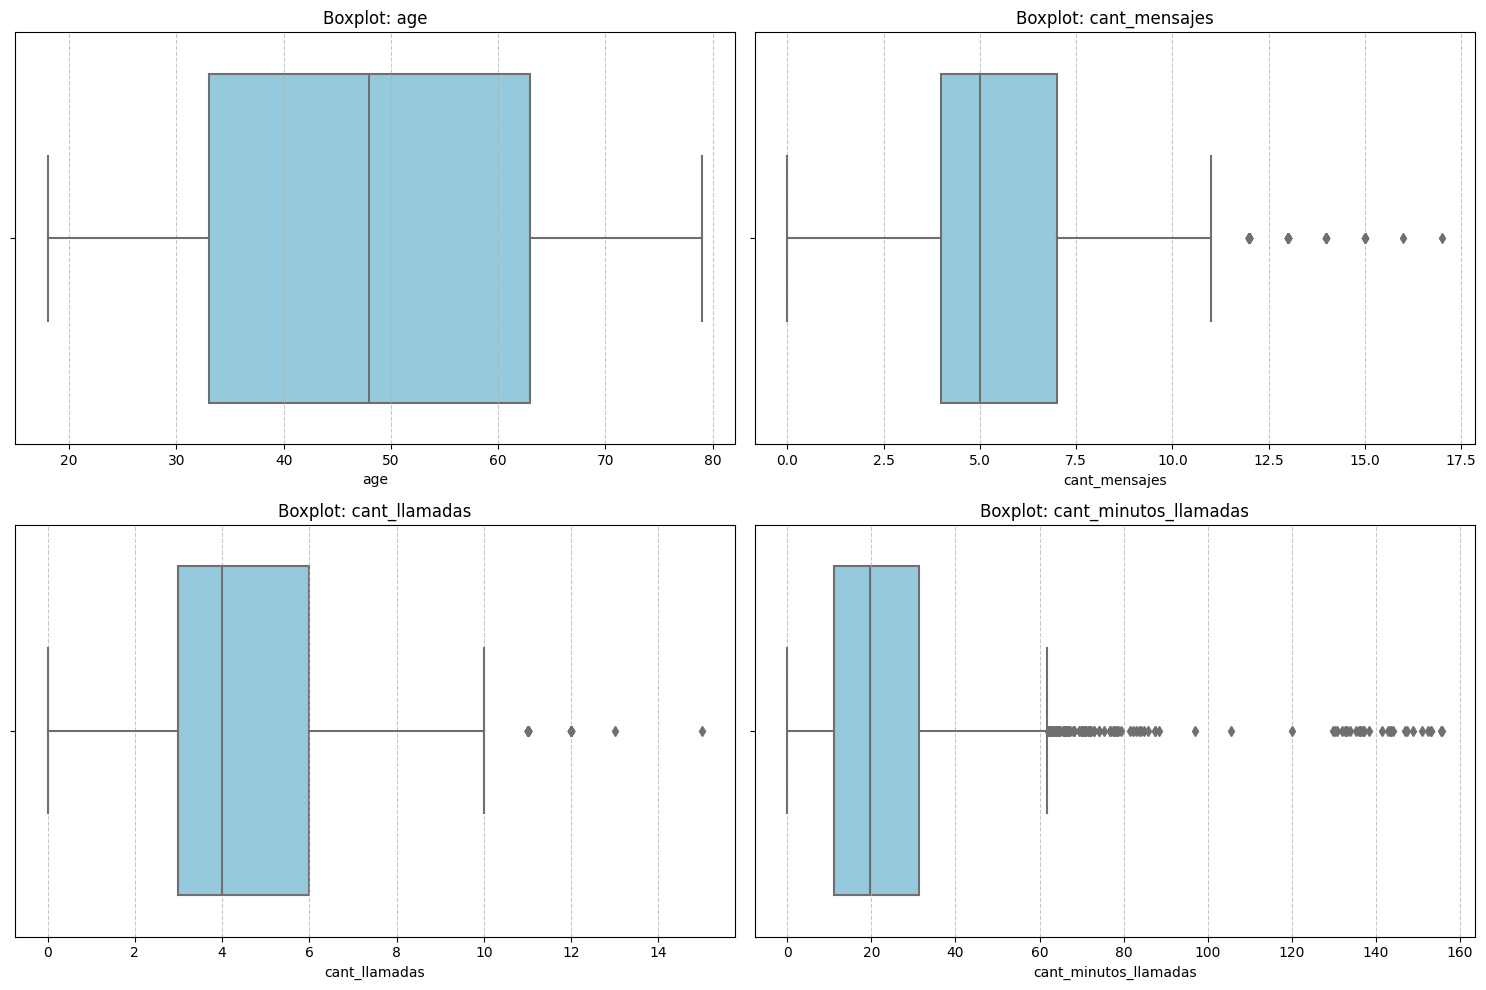

In [129]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamadas']
plt.figure(figsize=(15, 10))
for i, col in enumerate(columnas_numericas):
    plt.subplot(2, 2, i + 1) # Crea una cuadrícula de 2x2
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


💡Insights: 
- *Age*: No presenta outliers. La boxtplot está muy bien centrado y los "bigotes" cubren todo el rango de datos (de 18 a 80 años). Esto confirma que la base de clientes está distribuida de forma equilibrada en todas las edades sin valores extraños.
- *cant_mensajes*: Presenta outliers en el límite superior. Se observan puntos aislados a partir de los 11 mensajes. Estos son usuarios con un consumo de mensajería significativamente más alto que el promedio, aunque son pocos casos.
- *cant_llamadas*: Presenta outliers en el límite superior. A partir de las 10 llamadas, aparecen puntos que representan a usuarios con una frecuencia de llamadas inusual. El valor máximo llega hasta las 15 llamadas.
- *cant_minutos_llamadas*: Presenta una gran cantidad de outliers en el límite superior. Es la variable con más valores atípicos, comenzando desde los 60 minutos aproximadamente. Se observa una dispersión importante con usuarios que llegan hasta los 160 minutos, lo que indica la existencia de un segmento de "Heavy Users" que consumen mucho más tiempo del habitual.

✍️ A excepción de la edad, todas las variables de consumo presentan valores atípicos hacia la derecha. Se podrían mantener estos outliers en el dataset, ya que no parecen ser errores de medición, sino comportamientos reales de uso intensivo que son vitales para el análisis de rentabilidad y cobro de excedentes


In [135]:
# Calcular límites con el método IQR 
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamadas']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Solo calculamos el límite superior porque los outliers están a la derecha
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"--- Columna: {col} ---")
    print(f"Límite Superior (IQR): {limite_superior:.2f}")
    
    # Conteo de cuántos datos quedan fuera
    outliers_count = (user_profile[col] > limite_superior).sum()
    print(f"Cantidad de outliers detectados: {outliers_count}")

--- Columna: cant_mensajes ---
Límite Superior (IQR): 11.50
Cantidad de outliers detectados: 46
--- Columna: cant_llamadas ---
Límite Superior (IQR): 10.50
Cantidad de outliers detectados: 30
--- Columna: cant_minutos_llamadas ---
Límite Superior (IQR): 61.86
Cantidad de outliers detectados: 109


In [133]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamadas
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- *cant_mensajes*: Se detectaron 46 usuarios (aprox. 1.1% de la muestra) que superan el límite de 11.5 mensajes. Se pueden mantener porque el valor máximo (17) es perfectamente posible para un usuario real y no representa un error de sistema. Eliminarlos haría perder la visión de los clientes que más interactúan con este servicio.
- *cant_llamadas*: Se identificaron 30 outliers que realizan más de 10.5 llamadas. Se decide mantenerlos ya que el máximo de 15 llamadas es un comportamiento humano coherente. Estos usuarios representan el segmento de mayor actividad telefónica, esencial para entender el uso de la red.
- *cant_minutos_llamadas*: Es la variable con más valores atípicos (109 usuarios), con un límite de 61.86 y un máximo de 155.69 minutos. Es crítico mantenerlos porque estos usuarios son los "Heavy Users". En un modelo de negocio por suscripción, este grupo es el que genera la mayor rentabilidad por cobros de excedentes; ignorarlos resultaría en un análisis financiero incompleto y sesgado.

✍️ Tras el análisis estadístico, se concluye que los datos son consistentes y reflejan comportamientos de consumo reales. No se recomienda ninguna poda de datos (clipping) o eliminación, ya que los valores extremos son fundamentales para calcular el potencial de ingresos adicionales de la compañía.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [136]:
# Crear columna grupo_uso
def clasificar_uso(fila):
    # Regla 1: Bajo uso
    if fila['cant_llamadas'] < 5 and fila['cant_mensajes'] < 5:
        return 'Bajo uso'
    # Regla 2: Uso medio (se evalúa si no cumplió la primera)
    elif fila['cant_llamadas'] < 10 and fila['cant_mensajes'] < 10:
        return 'Uso medio'
    # Regla 3: El resto
    else:
        return 'Alto uso'

# Crear la nueva columna en el dataframe
user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)


In [137]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamadas,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [142]:
# Crear columna grupo_edad
def clasificar_edad(edad):
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'
user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

# Verificar cambios y ver la distribución de los grupos
print("Distribución por grupos de edad:")
print(user_profile['grupo_edad'].value_counts())
user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)


Distribución por grupos de edad:
Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


In [140]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamadas,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

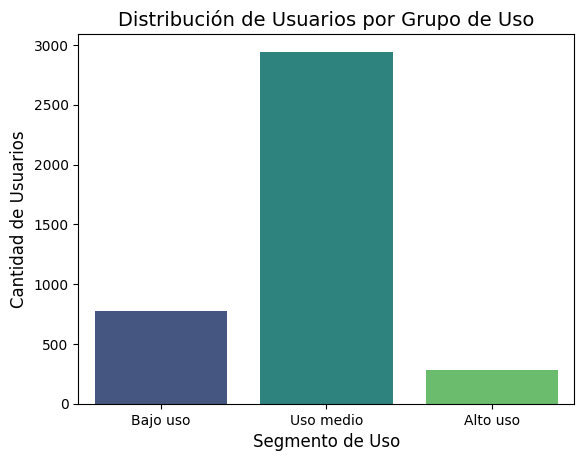

In [143]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso', palette='viridis', order=['Bajo uso', 'Uso medio', 'Alto uso'])

plt.title('Distribución de Usuarios por Grupo de Uso', fontsize=14)
plt.xlabel('Segmento de Uso', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.show()

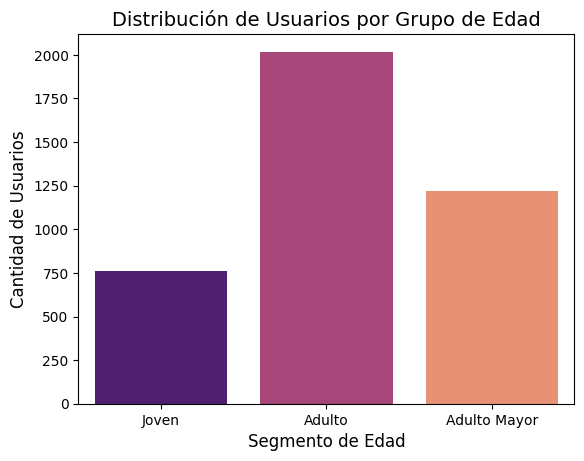

In [144]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette='magma', order=['Joven', 'Adulto', 'Adulto Mayor'])

plt.title('Distribución de Usuarios por Grupo de Edad', fontsize=14)
plt.xlabel('Segmento de Edad', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo
⚠️ **Problemas detectados en los datos**
Al inicio del proyecto, los datos presentaban inconsistencias que dificultaban un análisis preciso:
- *Registros incompletos*: Se identificó que aproximadamente el 25% de la base de usuarios no presentaba actividad registrada en las tablas de consumo. Para evitar sesgos, se imputaron estos valores con 0, permitiendo incluir a los usuarios "pasivos" en el perfil estadístico.
- *Nombres de columnas y tipos*: Fue necesario estandarizar los nombres de las variables (como cant_minutos_llamadas) para asegurar la integridad de los cálculos automáticos y bucles.

🔍 **Segmentos por Edad**
La segmentación demográfica revela una base de clientes de ConnectaTel madura y distribuida:
- *Adultos (30-60 años)*: Representan el grupo predominante. Su comportamiento es el más estable, con una distribución uniforme entre los planes Básico y Premium, se prodia decir que presentan un comportamiento de uso predecible y son la principal fuente de ingresos recurrentes.
- *Jóvenes (<30) y Adultos Mayores (>60)*: Aunque son grupos más pequeños, su distribución de contratación entre planes Básico y Premium es casi idéntica, lo que sugiere que la edad no es el factor determinante para elegir un plan superior, sino la necesidad técnica.

📊 **Segmentos por Nivel de Uso**
Se clasificó a los usuarios en tres niveles según su actividad:
- *Bajo Uso*: clientes que realizan < 5 llamadas y mensajes, mantienen su comunicación al mínimo. Son usuarios de bajo riesgo pero también de baja rentabilidad adicional.
- *Uso Medio*: El motor de la compañía. Usuarios que aprovechan los beneficios del plan pero rara vez se exceden, es decir que se mantienen dentro de los límites del plan. Es el segmento que percibe mayor valor por lo que paga.
- Alto Uso: Usuarios que superan las 10 llamadas o 12 mensajes o que superan los 60 minutos de voz. Representan la mayor oportunidad comercial. Este grupo es pequeño pero crítico, ya que genera una carga mayor en la red y es propenso a cobros por excedentes.

➡️ Esto sugiere que existe una brecha de valor importante. Muchos usuarios del Plan Básico están teniendo comportamientos de "Alto Uso", lo que significa que están pagando excedentes costosos en lugar de estar en un plan que se ajuste mejor a ellos. El Plan Premium no está siendo aprovechado por el volumen total de la base, sino por un nicho específico de consumo intensivo


💡 **Recomendaciones**
- *Migración Proactiva*: Identificar a los 109 outliers de minutos y a los clientes de "Alto Uso" que están en el Plan Básico para ofrecerles una actualización al Plan Premium. Esto mejora la lealtad del cliente al evitarle cobros sorpresa por excedentes.
- *Paquetes "Solo Voz" o "Solo Datos"*: Dado que el consumo de mensajes es muy bajo para la mayoría (moda de 5 mensajes), se podría crear un plan intermedio que priorice minutos de llamadas, que es donde reside el mayor uso y los mayores outliers.
- *Fidelización del Adulto Mayor*: Crear una oferta simplificada para este segmento, que tiene una presencia sólida en la base y muestra un uso de llamadas muy constante.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: https://github.com/mcrodriguez1508/ConnectaTel-Analysis